# Unemployment Analysis with Python

## Project Overview

This project analyzes unemployment trends in India using two datasets. The analysis focuses on data cleaning, exploration, visualization, the impact of Covid-19 on unemployment, and key insights that can support economic understanding.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets

In [2]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [3]:
print("Dataset 1")
df1.head()

Dataset 1


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
print("Dataset 2")
df2.head()

Dataset 2


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Dataset Overview

In [5]:
print("Dataset 1 Shape :", df1.shape)
print("Dataset 2 Shape :", df2.shape)

Dataset 1 Shape : (768, 7)
Dataset 2 Shape : (267, 9)


In [6]:
print("Dataset 1 Information")
df1.info()

print("\n" + "-"*60 + "\n")

print("Dataset 2 Information")
df2.info()

Dataset 1 Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

------------------------------------------------------------

Dataset 2 Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 col

In [7]:
df1.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,14,31-10-2019,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequency,740,2,Monthly,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,10.721298,0.0,4.6575,8.35,15.8875,76.74
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,8087988.429458,49420.0,1190404.5,4744178.5,11275489.5,45777509.0
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,8.111094,13.33,38.0625,41.16,45.505,72.57
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df2.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,267,27,Andhra Pradesh,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,267,10,31-03-2020,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequency,267,1,M,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated Unemployment Rate (%),267.0,NaN,NaN,NaN,12.236929,10.803283,0.5,4.845,9.65,16.755,75.85
Estimated Employed,267.0,NaN,NaN,NaN,13962105.722846,13366318.359733,117542.0,2838930.5,9732417.0,21878686.0,59433759.0
Estimated Labour Participation Rate (%),267.0,NaN,NaN,NaN,41.681573,7.845419,16.77,37.265,40.39,44.055,69.69
Region.1,267,5,North,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,267.0,NaN,NaN,NaN,22.826048,6.270731,10.8505,18.1124,23.6102,27.2784,33.7782
latitude,267.0,NaN,NaN,NaN,80.532425,5.831738,71.1924,76.0856,79.0193,85.2799,92.9376


## Data Cleaning

In [9]:
print("Missing Values in Dataset 1")
df1.isnull().sum()

Missing Values in Dataset 1


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [10]:
print("Missing Values in Dataset 2")
df2.isnull().sum()

Missing Values in Dataset 2


Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [11]:
print("Duplicate Records in Dataset 1 :", df1.duplicated().sum())

print("Duplicate Records in Dataset 2 :", df2.duplicated().sum())

Duplicate Records in Dataset 1 : 27
Duplicate Records in Dataset 2 : 0


In [12]:
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

In [13]:
print("Dataset 1 Shape :", df1.shape)
print("Dataset 2 Shape :", df2.shape)

Dataset 1 Shape : (741, 7)
Dataset 2 Shape : (267, 9)


### Observation

- Both datasets were loaded successfully.
- Missing values and duplicate records were checked.
- Duplicate records were removed where applicable.
- The datasets are now ready for exploratory data analysis.

## Data Preparation

In [16]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [17]:
df1["Date"] = pd.to_datetime(df1["Date"])

df2["Date"] = pd.to_datetime(df2["Date"])

In [18]:
df1["Month"] = df1["Date"].dt.month_name()
df1["Year"] = df1["Date"].dt.year

df2["Month"] = df2["Date"].dt.month_name()
df2["Year"] = df2["Date"].dt.year

### Observation

Date columns were converted into datetime format, and Month and Year features were extracted for trend analysis.

## Unemployment Rate Distribution

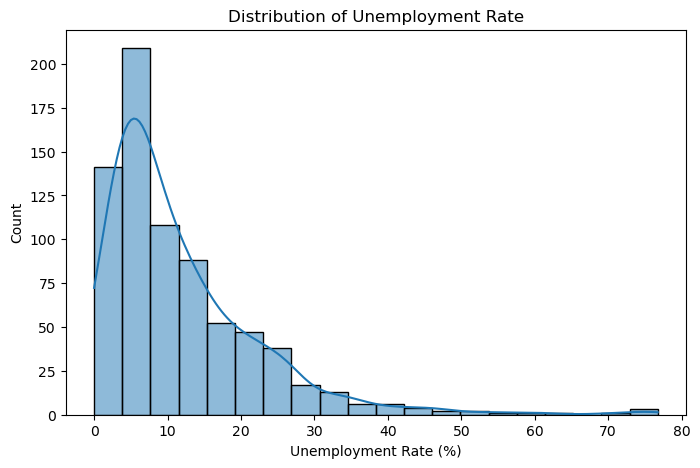

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df1["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")

plt.show()

**Observation**

Most unemployment rates are concentrated within a moderate range, with a few higher values.

## Correlation Heatmap

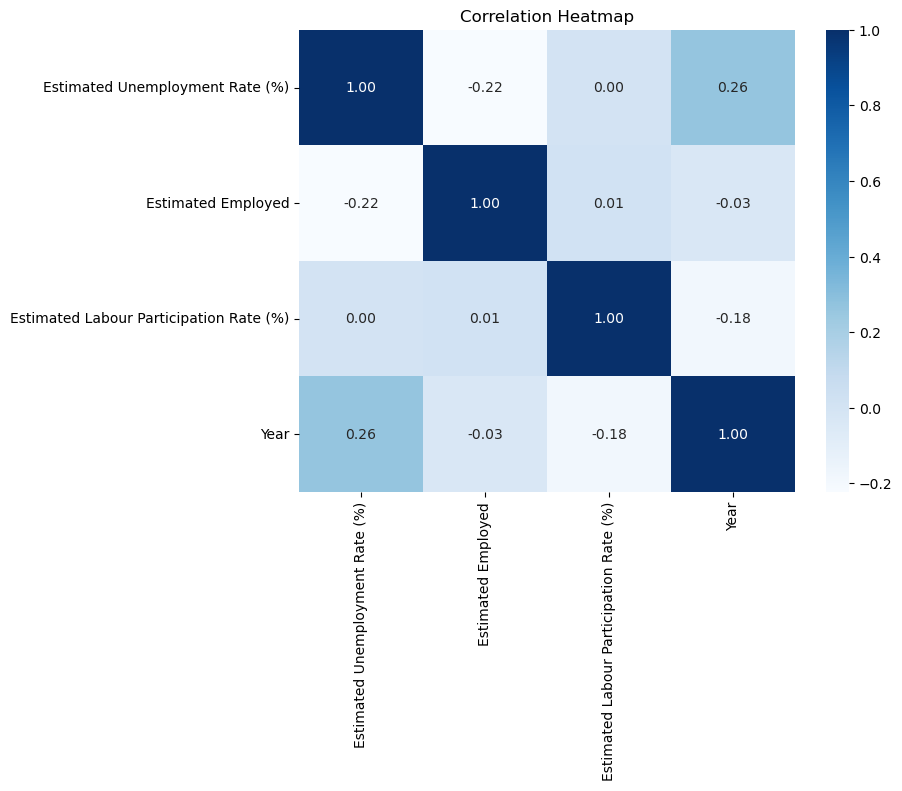

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**Observation**

The heatmap shows the relationship between unemployment rate, employment, and labour participation rate.

## State-wise Average Unemployment Rate

In [23]:
state_unemployment = (
    df1.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

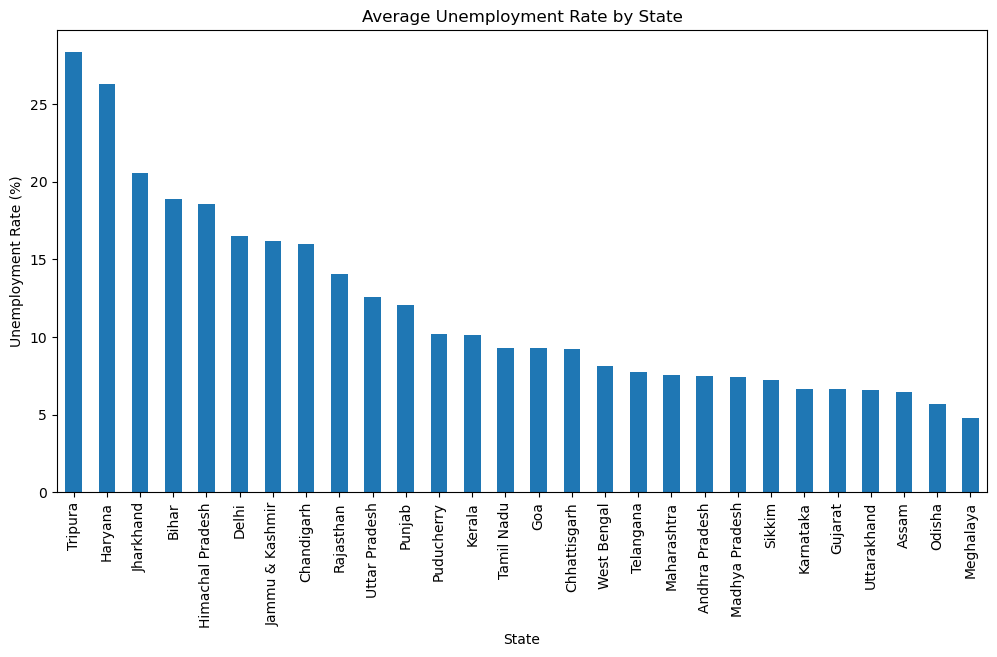

In [24]:
plt.figure(figsize=(12,6))

state_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

**Observation**

Some states have consistently higher unemployment rates than others, indicating regional differences in employment opportunities.

## Urban vs Rural Unemployment

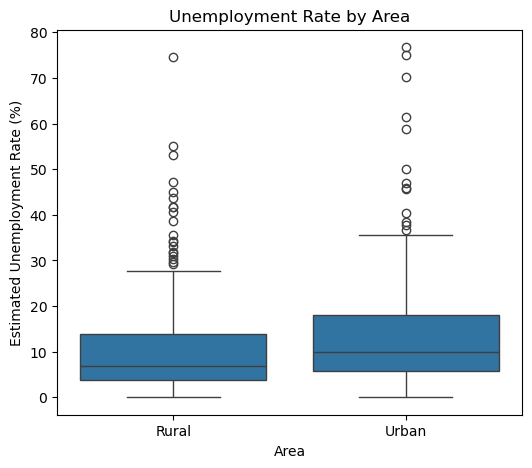

In [26]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df1,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Unemployment Rate by Area")

plt.show()

**Observation**

The distribution highlights the variation in unemployment rates between urban and rural areas.

## Monthly Unemployment Trend

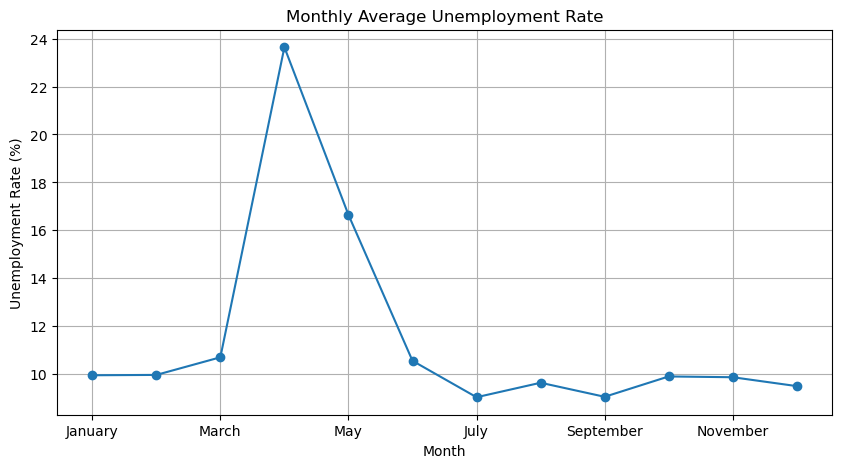

In [28]:
monthly_trend = (
    df1.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)
plt.figure(figsize=(10,5))

monthly_trend.plot(marker="o")

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

**Observation**

The monthly trend helps identify seasonal changes in unemployment throughout the year.

## Covid-19 Impact Analysis

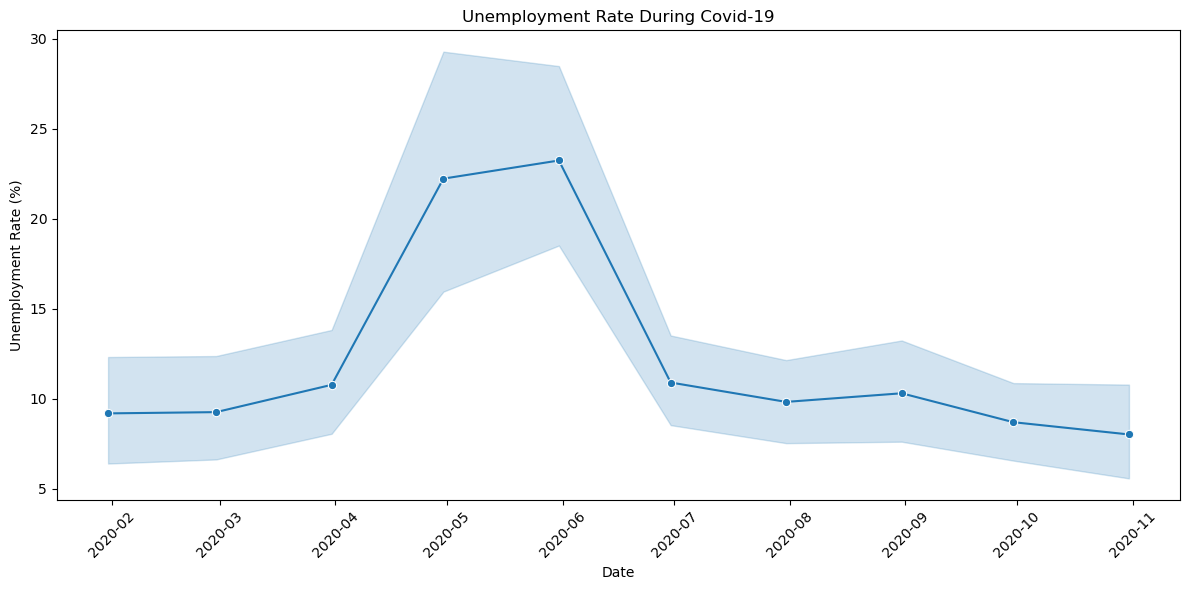

In [29]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df2,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Unemployment Rate During Covid-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation**

The unemployment rate shows noticeable fluctuations during the Covid-19 period, reflecting the economic impact of lockdowns and business disruptions.

## Top 10 States by Average Unemployment Rate

In [30]:
top_states = (
    df2.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

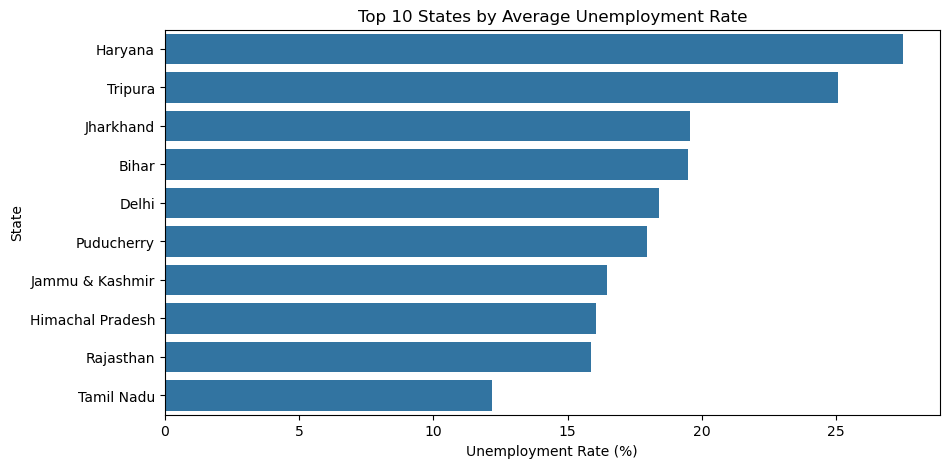

In [31]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

**Observation**

A few states experienced significantly higher unemployment levels during the Covid-19 period.

## Labour Participation Rate

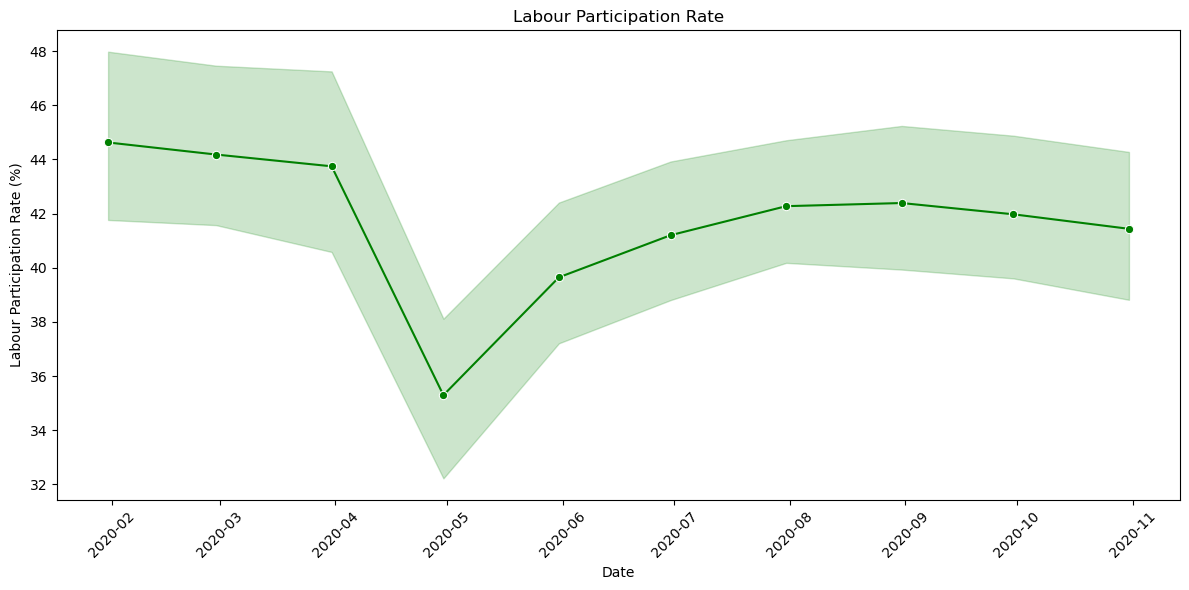

In [32]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df2,
    x="Date",
    y="Estimated Labour Participation Rate (%)",
    marker="o",
    color="green"
)

plt.title("Labour Participation Rate")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation**

Labour participation changed over time, indicating shifts in workforce availability during the pandemic.

## Estimated Employment Trend

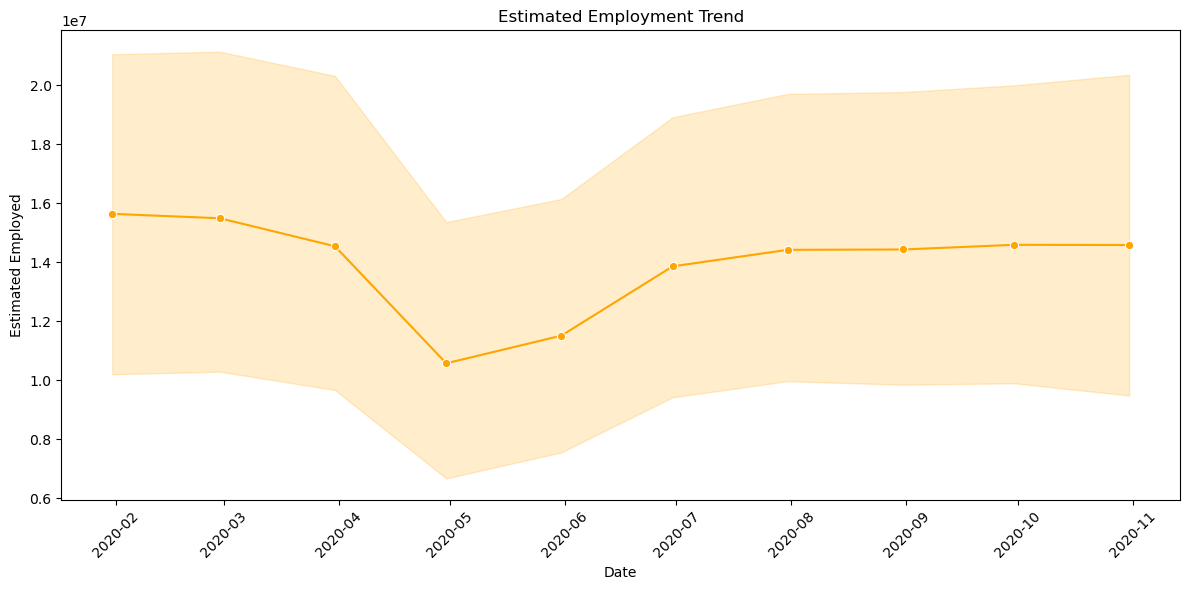

In [33]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df2,
    x="Date",
    y="Estimated Employed",
    marker="o",
    color="orange"
)

plt.title("Estimated Employment Trend")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation**

Employment levels declined during certain periods, highlighting the effect of Covid-19 on job availability.

## Region-wise Unemployment Rate

In [34]:
region_data = (
    df2.groupby("Region.1")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

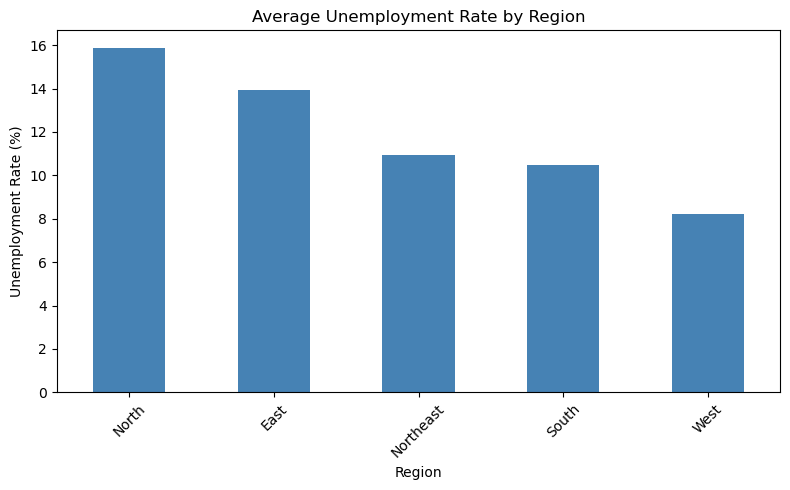

In [35]:
plt.figure(figsize=(8,5))

region_data.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation**

Average unemployment varied across regions, indicating that the impact of Covid-19 was not uniform throughout the country.

## Correlation Analysis (Covid Dataset)

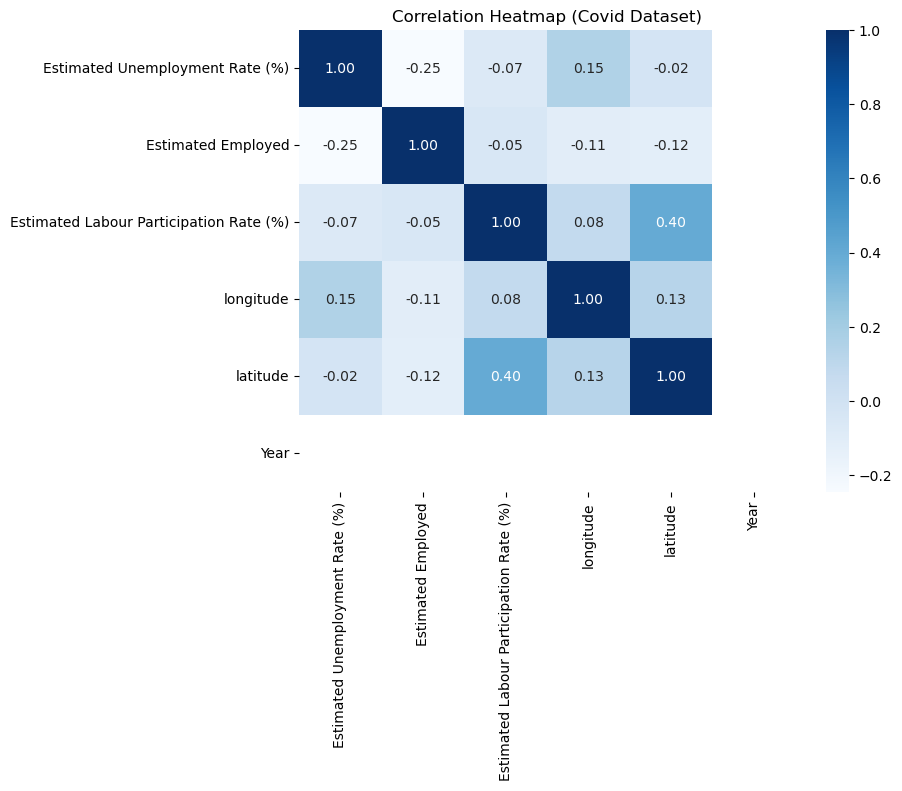

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap (Covid Dataset)")

plt.show()

**Observation**

The correlation matrix highlights relationships among unemployment rate, employment, labour participation, and geographical attributes.

## Key Insights

- Unemployment rates varied significantly across different states.
- The Covid-19 period showed noticeable changes in unemployment and employment levels.
- Labour participation also fluctuated during the pandemic.
- Some regions were more affected than others, indicating unequal economic impact.
- Seasonal variations were observed in monthly unemployment trends.

## Policy Recommendations

- Employment programs can be prioritized in regions with consistently high unemployment.
- Skill development initiatives may help improve employment opportunities.
- Labour market trends should be monitored regularly to support timely policy decisions.
- Government support during economic disruptions can reduce the impact on employment.
    

## Conclusion

This project explored unemployment trends in India using two datasets. After cleaning and analyzing the data, several visualizations were created to understand unemployment patterns, regional differences, and the impact of Covid-19. The analysis highlights how unemployment changed over time and provides insights that can support better economic planning and policy decisions.